In [4]:
import lsdb
from pathlib import Path
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
from lsst.daf.butler import Butler

In [8]:
repo = 'embargo'
collection = "LSSTCam/prompt/output-20260112"

butler = Butler(repo, collections=collection)

INFO:botocore.credentials:Found credentials in shared credentials file: /sdf/home/n/ncaplar/.lsst/aws-credentials.ini


In [4]:
test_DiaObject = pq.read_table('/sdf/scratch/rubin/ppdb/data/ppdb_lsstcam/2025/12/24/1766558400/DiaObject.parquet').to_pandas()
test_DiaSource = pq.read_table('/sdf/scratch/rubin/ppdb/data/ppdb_lsstcam/2025/12/24/1766558400/DiaSource.parquet').to_pandas()
np.sum(np.isnan(test_DiaSource['diaObjectId']))


np.int64(839)

In [9]:
parquet_path = "/sdf/scratch/rubin/ppdb/data/ppdb_lsstcam/2025/12/24/1766558400/DiaObject.parquet"
pf = pq.ParquetFile(parquet_path)

rg = 0
obj_lc_parquet_file = pf  # <- use your file here

obj_lc_cols = obj_lc_parquet_file.metadata.num_columns
obj_lc_sizes = np.zeros(obj_lc_cols, dtype=np.int64)
row_groups = obj_lc_parquet_file.metadata.num_row_groups
obj_lc_lens = np.zeros(obj_lc_cols, dtype=np.int64)

for rg in range(row_groups):
    rg_meta = obj_lc_parquet_file.metadata.row_group(rg)
    for col in range(obj_lc_cols):
        col_meta = rg_meta.column(col)
        obj_lc_sizes[col] += col_meta.total_compressed_size
        obj_lc_lens[col] += col_meta.num_values

first_row_group = obj_lc_parquet_file.metadata.row_group(0)

column_names = [
    first_row_group.column(col).path_in_schema.removesuffix(".list.element")
    for col in range(first_row_group.num_columns)
]

column_types = [
    first_row_group.column(col).physical_type
    for col in range(first_row_group.num_columns)
]

obj_lc_frame = pd.DataFrame(
    {
        "name": column_names,
        "size": obj_lc_sizes,
        "length": obj_lc_lens,
        "type": column_types,
    }
)
obj_lc_frame["percent"] = obj_lc_frame["size"] / obj_lc_frame["size"].sum() * 100
obj_lc_frame["density"] = obj_lc_frame["size"] / obj_lc_frame["length"]
obj_lc_frame = obj_lc_frame.sort_values("density", ascending=False)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 200)

obj_lc_frame

,name,size,length,type,percent,density
3,dec,71091,7373,DOUBLE,11.931263,9.642072
44,ra,71091,7373,DOUBLE,11.931263,9.642072
11,g_psfFluxMean,41583,7373,FLOAT,6.978910,5.639902
13,g_psfFluxMin,41579,7373,FLOAT,6.978239,5.639360
16,g_scienceFluxMean,41579,7373,FLOAT,6.978239,5.639360
9,g_psfFluxMax,41575,7373,FLOAT,6.977568,5.638817
8,g_psfFluxErrMean,41575,7373,FLOAT,6.977568,5.638817
12,g_psfFluxMeanErr,41575,7373,FLOAT,6.977568,5.638817
17,g_scienceFluxMeanErr,41547,7373,FLOAT,6.972868,5.635020
1,diaObjectId,40878,7373,INT64,6.860590,5.544283


In [5]:
test_DiaSource['diaObjectId']

0       1.697470e+17
1       1.697778e+17
            ...     
8210    1.697778e+17
8211    1.697602e+17
Name: diaObjectId, Length: 8212, dtype: float64

In [6]:
ppdb_hats = lsdb.open_catalog('/sdf/data/rubin/shared/lsdb_commissioning/ppdb/dia_object_collection')

In [9]:
ppdb_hats.nested_columns

['diaSource']

In [7]:
ppdb_hats

,apdb_replica_chunk,diaObjectId,validityStartMjdTai,dec,decErr,firstDiaSourceMjdTai,g_fpFluxMean,g_fpFluxMeanErr,g_psfFluxErrMean,g_psfFluxMax,g_psfFluxMaxSlope,g_psfFluxMean,g_psfFluxMeanErr,g_psfFluxMin,g_psfFluxNdata,g_psfFluxSigma,g_scienceFluxMean,g_scienceFluxMeanErr,i_fpFluxMean,i_fpFluxMeanErr,i_psfFluxErrMean,i_psfFluxMax,i_psfFluxMaxSlope,i_psfFluxMean,i_psfFluxMeanErr,i_psfFluxMin,i_psfFluxNdata,i_psfFluxSigma,i_scienceFluxMean,i_scienceFluxMeanErr,lastDiaSourceMjdTai,nDiaSources,r_fpFluxMean,r_fpFluxMeanErr,r_psfFluxErrMean,r_psfFluxMax,r_psfFluxMaxSlope,r_psfFluxMean,r_psfFluxMeanErr,r_psfFluxMin,r_psfFluxNdata,r_psfFluxSigma,r_scienceFluxMean,r_scienceFluxMeanErr,ra,raErr,ra_dec_Cov,u_fpFluxMean,u_fpFluxMeanErr,u_psfFluxErrMean,u_psfFluxMax,u_psfFluxMaxSlope,u_psfFluxMean,u_psfFluxMeanErr,u_psfFluxMin,u_psfFluxNdata,u_psfFluxSigma,u_scienceFluxMean,u_scienceFluxMeanErr,validityEndMjdTai,y_fpFluxMean,y_fpFluxMeanErr,y_psfFluxErrMean,y_psfFluxMax,y_psfFluxMaxSlope,y_psfFluxMean,y_psfFluxMeanErr,y_psfFluxMin,y_psfFluxNdata,y_psfFluxSigma,y_scienceFluxMean,y_scienceFluxMeanErr,z_fpFluxMean,z_fpFluxMeanErr,z_psfFluxErrMean,z_psfFluxMax,z_psfFluxMaxSlope,z_psfFluxMean,z_psfFluxMeanErr,z_psfFluxMin,z_psfFluxNdata,z_psfFluxSigma,z_scienceFluxMean,z_scienceFluxMeanErr,u_scienceMagMean,u_scienceMagMeanErr,g_scienceMagMean,g_scienceMagMeanErr,r_scienceMagMean,r_scienceMagMeanErr,i_scienceMagMean,i_scienceMagMeanErr,z_scienceMagMean,z_scienceMagMeanErr,y_scienceMagMean,y_scienceMagMeanErr,diaSource
npartitions=6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 2, Pixel: 106",int64[pyarrow],int64[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<apdb_replica_chunk: [int64], diaSourceI..."
"Order: 1, Pixel: 33",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 10",...,...,...,...,...,..

In [71]:
ppdb_hats.all_columns

['apdb_replica_chunk',
 'diaObjectId',
 'validityStartMjdTai',
 'dec',
 'decErr',
 'firstDiaSourceMjdTai',
 'g_fpFluxMean',
 'g_fpFluxMeanErr',
 'g_psfFluxErrMean',
 'g_psfFluxMax',
 'g_psfFluxMaxSlope',
 'g_psfFluxMean',
 'g_psfFluxMeanErr',
 'g_psfFluxMin',
 'g_psfFluxNdata',
 'g_psfFluxSigma',
 'g_scienceFluxMean',
 'g_scienceFluxMeanErr',
 'i_fpFluxMean',
 'i_fpFluxMeanErr',
 'i_psfFluxErrMean',
 'i_psfFluxMax',
 'i_psfFluxMaxSlope',
 'i_psfFluxMean',
 'i_psfFluxMeanErr',
 'i_psfFluxMin',
 'i_psfFluxNdata',
 'i_psfFluxSigma',
 'i_scienceFluxMean',
 'i_scienceFluxMeanErr',
 'lastDiaSourceMjdTai',
 'nDiaSources',
 'r_fpFluxMean',
 'r_fpFluxMeanErr',
 'r_psfFluxErrMean',
 'r_psfFluxMax',
 'r_psfFluxMaxSlope',
 'r_psfFluxMean',
 'r_psfFluxMeanErr',
 'r_psfFluxMin',
 'r_psfFluxNdata',
 'r_psfFluxSigma',
 'r_scienceFluxMean',
 'r_scienceFluxMeanErr',
 'ra',
 'raErr',
 'ra_dec_Cov',
 'u_fpFluxMean',
 'u_fpFluxMeanErr',
 'u_psfFluxErrMean',
 'u_psfFluxMax',
 'u_psfFluxMaxSlope',
 'u_psfFlu

In [56]:
test_df.iloc[0]['diaSource'].shape

(1, 101)

In [ ]:
# Shape of the nested 'diaSource' value for each row
# (handles missing/None entries safely)
diaSource_shapes = test_df[119010:120000]["diaObjectId", "diaSource"].map(lambda x: getattr(x, "shape", None))

# Optional: attach as a new column
# test_df = test_df.assign(diaSource_shape=diaSource_shapes)

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7f5d76d37a60>
Traceback (most recent call last):
  File "/sdf/group/rubin/sw/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
test_df.tail(15)['diaObjectId','diaSource']

diaObjectId  \
_healpix_29                               
3445339733663553678  169368790942351590   
3445339870375236035  169368790942351710   
3445339940876538536  169368790942351658   
3445340148570465637  169368790942351587   
3445340342317359345  169368790942351613   
3445340780687431748  169368790942351771   
3445341176363979849  169368790942351707   
3445341301024132072  169368790942351673   
3445341340604368927  169368790942351767   
3445360799273569187  169368790942351374   
3445361429661698125  169368790942351385   
3445361429986417564  169368790942351389   
3445364055065569735  169368790942351593   
3445364114942747732  169368790942351525   
3445364339133530320  169368790942351479   

                                                             diaSource  
_healpix_29                                                             
3445339733663553678  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445339870375236035  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445339940876538536  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445340148570465637  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445340342317359345  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445340780687431748  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445341176363979849  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445341301024132072  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445341340604368927  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445360799273569187  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445361429661698125  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445361429986417564  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445364055065569735  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445364114942747732  [{apdb_replica_chunk: 1758511800, diaSourceId:...  
3445364339133530320  [{apdb_replica_chunk: 1758511800, diaSourceId:...

In [102]:
diaSource_shapes

,diaObjectId,diaSource
_healpix_29,,
1923403098161047583,None,"(1, 101)"
1923404688525799921,None,"(1, 101)"
...,...,...
1917985841493845027,None,None
1917997670204598170,None,None


In [90]:
import lsdb
from lsdb.nested import count_nested
dia_collection = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/ppdb/dia_object_collection")
t = count_nested(dia_collection[["validityStartMjdTai", "lastDiaSourceMjdTai", "diaObjectId","diaSource"]]._ddf, "diaSource").compute()
t[t["n_diaSource"] == 0]

,validityStartMjdTai,lastDiaSourceMjdTai,diaObjectId,diaSource,n_diaSource
1923442442929667548,61026.214844,,169747015092667870,None,0
1923443908696145808,61026.214844,,169747015092667687,None,0
1923444025942308037,61026.214844,,169747015092667627,None,0
1923444693123181380,61026.214844,,169747015092667617,None,0
1923456381389280578,61026.214844,,169747015093192462,None,0
...,...,...,...,...,...


In [94]:
validityStartMjdTai = dia_collection['validityStartMjdTai'].compute()
t0 = t[t["n_diaSource"] == 0]
len(validityStartMjdTai)

663304

In [88]:
min_validity = np.min(validityStartMjdTai)
max_validity = np.max(validityStartMjdTai)
np.ar = np.linspace(min_validity, max_validity, 50)

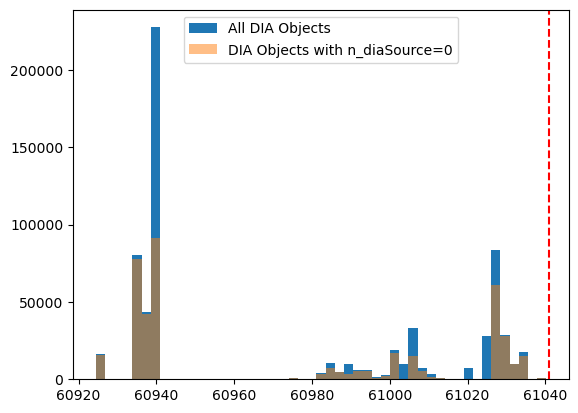

In [99]:
plt.hist(validityStartMjdTai, bins=np.ar, label='All DIA Objects');
plt.hist(t0['validityStartMjdTai'], bins=np.ar, alpha=0.5, label='DIA Objects with n_diaSource=0');
plt.legend();
plt.axvline(61041, color='red', linestyle='--', label='Jan 01, 2026');

## Discover available collections
If you get `MissingCollectionError`, the collection string doesn’t exist in this `repo`. Use the registry to list and filter collections, then plug a valid name into `Butler(..., collections=...)`.

In [4]:
import itertools
from lsst.daf.butler import CollectionType

# 1) Quick sanity check: list a small sample of collections
sample = list(itertools.islice(butler.registry.queryCollections(), 50))
sample[:10], len(sample)

(['skymaps',
  'refcats/DM-49042/the_monster_20250219',
  'LSSTCam/calib/DM-49175/run7/bfkGen.20250320a/20250324T220123Z',
  'LSSTCam/calib/DM-49175/run7/biasGen.20250320a/20250325T205118Z',
  'LSSTCam/calib/DM-49175/run7/ctiGen.20250320a/20250325T152139Z',
  'LSSTCam/calib/DM-49175/run7/darkGen.20250320a/20250326T000943Z',
  'LSSTCam/calib/DM-49175/run7/defectGen.20250401a/20250401T232630Z',
  'LSSTCam/calib/DM-49175/run7/linearizerGen.20250320a/20250321T052032Z',
  'LSSTCam/calib/DM-49175/run7/ptcGen.20250320a/20250323T161738Z',
  'LSSTCam/calib/DM-49175/run7/bfk.20250320a'],
 50)

In [5]:
# 2) Filter by name glob and type (RUN/CHAINED/TAGGED/CALIBRATION)
prompt_run_collections = sorted(
    butler.registry.queryCollections(
        "LSSTCam/prompt/output-*",
        collectionTypes={CollectionType.RUN},
    )
 )
prompt_run_collections[-10:]  # show most recent-ish by sort order

['LSSTCam/prompt/output-2026-01-17/Isr/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-17/NoPipeline/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-17/Preprocessing-noForced/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-17/SingleFrame/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/ApPipe-noForced/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/Isr-cal/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/Isr/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/NoPipeline/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/Preprocessing-noForced/pipelines-ece89d7-config-8f017ea',
 'LSSTCam/prompt/output-2026-01-18/SingleFrame/pipelines-ece89d7-config-8f017ea']

In [6]:
# 3) If you intended a CHAINED collection, list those too
prompt_chained = sorted(
    butler.registry.queryCollections(
        "LSSTCam/prompt/*",
        collectionTypes={CollectionType.CHAINED},
    )
 )
prompt_chained[:30]

['LSSTCam/prompt/output-2025-11-21',
 'LSSTCam/prompt/output-2025-12-09',
 'LSSTCam/prompt/output-2025-12-09/daytime',
 'LSSTCam/prompt/output-2025-12-10',
 'LSSTCam/prompt/output-2025-12-11',
 'LSSTCam/prompt/output-2025-12-12',
 'LSSTCam/prompt/output-2025-12-13',
 'LSSTCam/prompt/output-2025-12-14',
 'LSSTCam/prompt/output-2025-12-15',
 'LSSTCam/prompt/output-2025-12-16',
 'LSSTCam/prompt/output-2025-12-17',
 'LSSTCam/prompt/output-2025-12-18',
 'LSSTCam/prompt/output-2025-12-19',
 'LSSTCam/prompt/output-2025-12-20',
 'LSSTCam/prompt/output-2025-12-21',
 'LSSTCam/prompt/output-2025-12-22',
 'LSSTCam/prompt/output-2025-12-23',
 'LSSTCam/prompt/output-2025-12-24',
 'LSSTCam/prompt/output-2025-12-25',
 'LSSTCam/prompt/output-2025-12-26',
 'LSSTCam/prompt/output-2025-12-27',
 'LSSTCam/prompt/output-2025-12-28',
 'LSSTCam/prompt/output-2025-12-29',
 'LSSTCam/prompt/output-2025-12-30',
 'LSSTCam/prompt/output-2025-12-30/daytime',
 'LSSTCam/prompt/output-2025-12-31',
 'LSSTCam/prompt/outpu

In [7]:
dt = butler.registry.getDatasetType("dia_object_apdb")
dt.dimensions.names

{band, instrument, day_obs, detector, physical_filter, visit}

In [12]:
collection = "LSSTCam/prompt/output-2025-12-16"

butler = Butler(repo, collections=collection)

In [13]:
dia_obj_refs= butler.query_datasets("dia_object_apdb")
dia_src_refs= butler.query_datasets("dia_source_apdb")

In [14]:
collection = "LSSTCam/prompt/output-2026-01-17"

butler = Butler(repo, collections=collection)

In [ ]:
dia_obj_refs= butler.query_datasets("dia_object_apdb")
dia_src_refs= butler.query_datasets("dia_source_apdb")

In [15]:
len(dia_obj_refs)

5598

In [16]:
# all dataset type names
names = sorted(dt.name for dt in butler.registry.queryDatasetTypes())
names[:50], len(names)

pattern = "source"  # or "calexp", "src", "apdb", ...
matches = sorted(dt.name for dt in butler.registry.queryDatasetTypes(f"*{pattern}*"))
matches


['dia_forced_source_apdb',
 'dia_source',
 'dia_source_apdb',
 'dia_source_detector',
 'dia_source_high_reliability',
 'dia_source_low_reliability',
 'dia_source_patch',
 'dia_source_reliability',
 'dia_source_schema',
 'dia_source_unfiltered',
 'dia_source_unstandardized',
 'dia_source_visit',
 'difference_kernel_sources',
 'long_trailed_dia_source',
 'long_trailed_source_detector',
 'marginal_new_dia_source',
 'new_dia_source',
 'preloaded_dia_forced_source',
 'preloaded_dia_source',
 'reassociated_dia_source_patch',
 'rejected_dia_source',
 'ss_source_associated',
 'ss_source_detector',
 'ss_source_direct_detector',
 'ss_source_direct_detector_metrics']